In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
!pip install --upgrade pip
!pip install --upgrade jiwer evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 44.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [evaluate]


In [6]:
import datasets
import transformers
import soundfile
import librosa
import tensorboard
import jiwer
import evaluate


In [8]:
from huggingface_hub import notebook_login
notebook_login()

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Configuration
DATASET_ID = "google/WaxalNLP"
LANGUAGES = ["lin", "lug", "sna"]
TARGET_SAMPLE_RATE = 16_000
SAMPLE_SIZE = 500
eda_metrics = []
unique_chars = {lang: set() for lang in LANGUAGES}

Initializing streams: 


README.md:   0%|          | 0.00/31.5k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/67 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Data collection complete!

Unique characters in LIN:
 -> 
 !',-.28;abcdefghijklmnopqrstuvwxyzâçéîñô

Unique characters in LUG:
 -> 
 !"',-.:;?abcdefghijklmnoprstuvwyzŋ

Unique characters in SNA:
 -> 
 "'(),-.;`abcdefghijklmnopqrstuvwxyzàí

Text Length Summary (Word Count):
          count   mean    std  min   25%   50%   75%   max
language                                                  
lin       500.0  26.84  11.75  4.0  19.0  26.0  34.0  73.0
lug       500.0  28.86  12.05  8.0  20.0  28.0  35.0  90.0
sna       500.0  23.62   7.81  3.0  18.0  23.0  28.0  51.0


Audio Duration Summary (Seconds):
          count   mean   std   min    25%    50%    75%    max
language                                                      
lin       500.0  17.41  6.67  1.01  15.58  17.38  20.56  35.62
lug       500.0  24.37  8.02  4.93  18.76  22.16  28.10  44.21
sna       500.0  20.72  4.89  1.01  17.50  19.80  23.38  35.66


Found 10 potentially silent/corrupted files out of 1500.
language
lin    10
dt

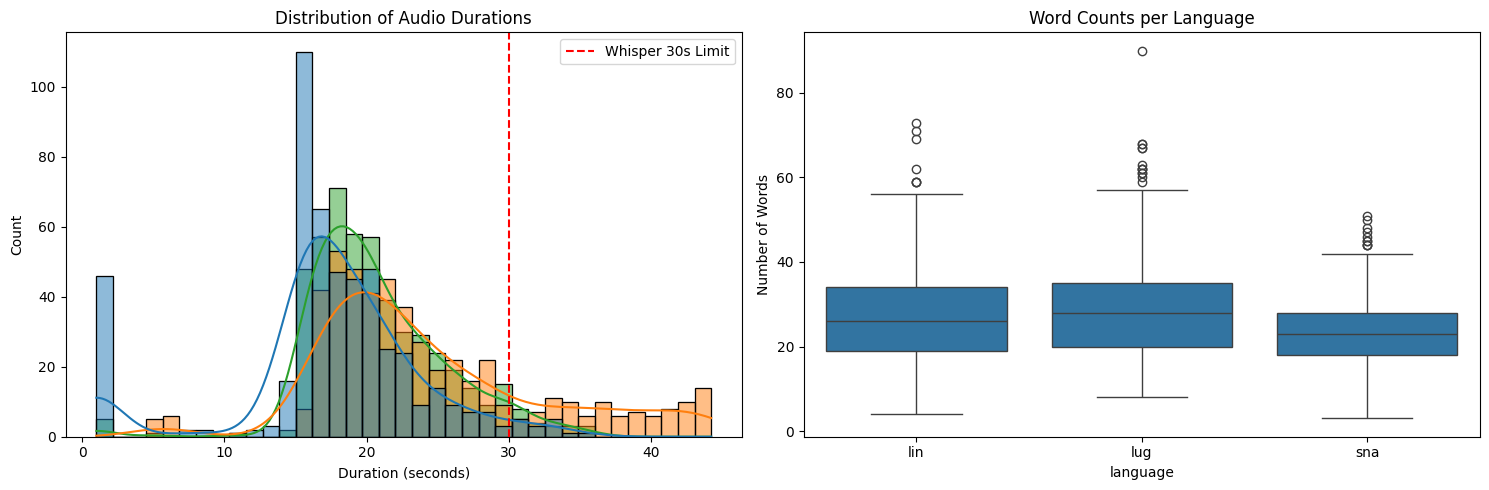

In [13]:
print("Initializing streams: ")

for lang in LANGUAGES:

    raw_stream = datasets.load_dataset(
        DATASET_ID,
        name=f"{lang}_asr",
        split="train",
        streaming=True
    )

    # Cast audio to 16kHz so it arrives ready for Whisper
    resampled_stream = raw_stream.cast_column(
        "audio",
        datasets.Audio(sampling_rate=TARGET_SAMPLE_RATE)
    )

    # Take a representative sample from the stream
    sample_stream = resampled_stream.take(SAMPLE_SIZE)

    for i, example in enumerate(sample_stream):
        text = example["transcription"]
        audio_array = example["audio"]["array"]

        #  Text Metrics
        # If text is missing or None, we catch it
        if text is None: text = ""

        word_count = len(text.split())
        char_count = len(text)

        # Collect unique characters for alphabet verification
        # We lowercase everything to simplify the character set
        unique_chars[lang].update(list(text.lower()))

        #  Audio Metrics
        # Duration = total number of samples / sampling rate
        duration_sec = len(audio_array) / TARGET_SAMPLE_RATE

        # Max amplitude checks for "dead" or completely silent audio files
        # If max amplitude is 0.0, the audio is completely silent
        max_amplitude = float(np.max(np.abs(audio_array)))

        eda_metrics.append({
            "language": lang,
            "text": text,
            "word_count": word_count,
            "char_count": char_count,
            "duration_sec": duration_sec,
            "max_amplitude": max_amplitude
        })

# Convert to a Pandas DataFrame for easy analysis
df_eda = pd.DataFrame(eda_metrics)
print("Data collection complete!\n")


#Unique characters
for lang in LANGUAGES:
    chars = sorted(list(unique_chars[lang]))
    print(f"Unique characters in {lang.upper()}:")
    print(f" -> {''.join(chars)}\n")

# B. Text Length Statistics
# WHAT THIS MEANS: Look at the max and min word counts. Are there transcripts with
# 0 words? Are there transcripts with 100 words that might get cut off?
print("Text Length Summary (Word Count):")
print(df_eda.groupby("language")["word_count"].describe().round(2))
print("\n")

# C. Audio Duration Statistics
# WHAT THIS MEANS: Whisper natively processes 30-second windows.
# If 'max' duration > 30s, the end of those files will be truncated and the
# model will hallucinate text. If 'min' < 1s, the audio might be too short to contain speech.
print("Audio Duration Summary (Seconds):")
print(df_eda.groupby("language")["duration_sec"].describe().round(2))
print("\n")

# D. Silence / Corruption Check
# WHAT THIS MEANS: If max_amplitude is exactly 0.0 or very close to it (e.g., 0.0001),
# the microphone was dead or the file is corrupted. You should filter these out of training.
silent_files = df_eda[df_eda["max_amplitude"] < 0.01]
print(f"Found {len(silent_files)} potentially silent/corrupted files out of {len(df_eda)}.")
if len(silent_files) > 0:
    print(silent_files.groupby("language").size())


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Audio Duration Distribution
# WHY DO THIS: A visual check to ensure the bulk of your data sits comfortably
# beneath the 30-second Whisper limitation.
sns.histplot(data=df_eda, x="duration_sec", hue="language", kde=True, ax=axes[0])
axes[0].set_title("Distribution of Audio Durations")
axes[0].set_xlabel("Duration (seconds)")
axes[0].axvline(30, color='red', linestyle='--', label='Whisper 30s Limit')
axes[0].legend()

# Plot 2: Text Word Count Distribution
# WHY DO THIS: Helps you gauge the verbosity of the languages. Luganda, for example,
# might use fewer, longer words (highly agglutinative) compared to others.
sns.boxplot(data=df_eda, x="language", y="word_count", ax=axes[1])
axes[1].set_title("Word Counts per Language")
axes[1].set_ylabel("Number of Words")

plt.tight_layout()
plt.show()